正在生成波浪角度数据...
✅ 已保存波浪角度数据到: 000063.SZ_wave_angles.csv (2435 个波浪)
特征提取完成，特征维度: (2435, 2)
特征统计:
       directed_angle_deg     duration
count         2435.000000  2435.000000
mean             4.233060    14.315400
std              5.666964    12.579832
min             -4.134475     1.000000
25%              1.432096     6.000000
50%              2.576572    10.000000
75%              4.573921    19.000000
max             54.845822   112.000000
聚类完成，状态分布: Counter({np.int32(0): 1296, np.int32(3): 657, np.int32(2): 276, np.int32(4): 155, np.int32(1): 51})

聚类统计:
   cluster_id cluster_type  count  percentage  angle_mean  duration_mean
0           0         短期震荡   1296   53.223819    3.080188       8.297068
1           1         急涨脉冲     51    2.094456   33.875947       1.333333
2           2         急涨脉冲    276   11.334702   11.319370       4.753623
3           3         长期盘整    657   26.981520    1.920882      22.969559
4           4         长期盘整    155    6.365503    1.301536      49.251613

C:\Users\Admin\AppData\Local\Temp\ipykernel_6736\261876003.py:749: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(cluster_angles, labels=[f'状态 {i}' for i in range(self.n_clusters)])


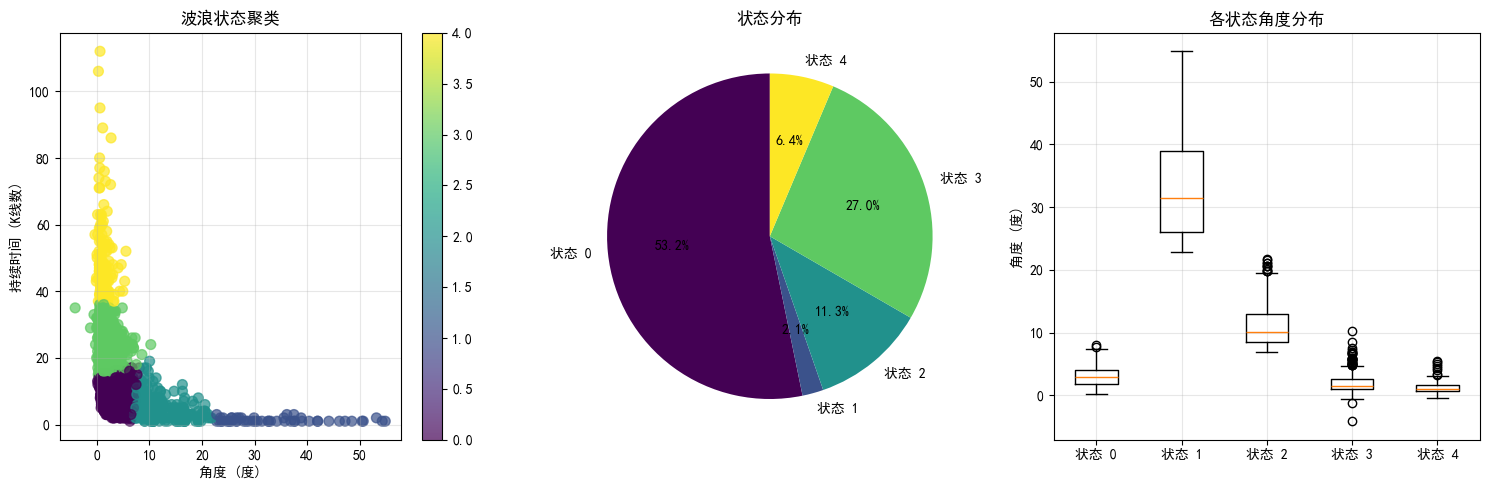

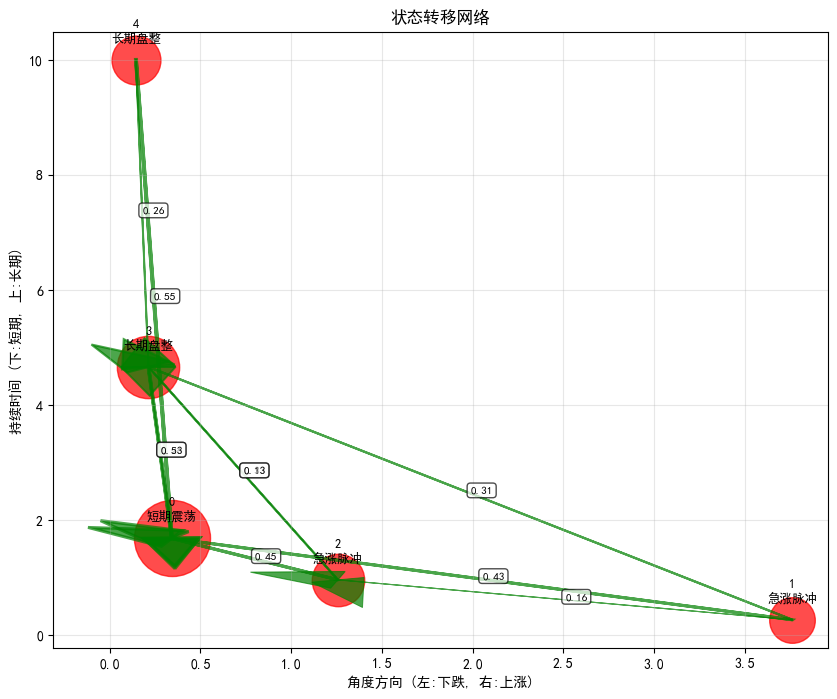

In [3]:
import pandas as pd
import numpy as np
import math
from scipy.signal import argrelextrema
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from pathlib import Path
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import math
from scipy.signal import argrelextrema
from sklearn.cluster import KMeans
from pathlib import Path
# 设置中文字体
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False


# ========== 保持你原有的所有函数不变 ==========
def detect_high_low_points(df, window=5):
    """可靠检测高点和低点极点"""
    if 'high' not in df.columns or 'low' not in df.columns:
        raise ValueError("DataFrame必须包含'high'和'low'列")
    
    high_prices = df['high'].values
    low_prices = df['low'].values
    
    high_indices = argrelextrema(high_prices, np.greater, order=window)[0]
    low_indices = argrelextrema(low_prices, np.less, order=window)[0]
    
    if len(df) > 0:
        if len(high_prices) > 0 and high_prices[0] >= max(high_prices[:min(3, len(high_prices))]):
            if 0 not in high_indices:
                high_indices = np.insert(high_indices, 0, 0)
        if len(low_prices) > 0 and low_prices[0] <= min(low_prices[:min(3, len(low_prices))]):
            if 0 not in low_indices:
                low_indices = np.insert(low_indices, 0, 0)
        if len(high_prices) > 0 and high_prices[-1] >= max(high_prices[-min(3, len(high_prices)):]):
            if len(high_prices)-1 not in high_indices:
                high_indices = np.append(high_indices, len(high_prices)-1)
        if len(low_prices) > 0 and low_prices[-1] <= min(low_prices[-min(3, len(low_prices)):]):
            if len(low_prices)-1 not in low_indices:
                low_indices = np.append(low_indices, len(low_prices)-1)
    
    df = df.copy()
    df['is_high'] = False
    df['is_low'] = False
    df['is_extreme_high'] = False
    df['is_extreme_low'] = False
    
    df.iloc[high_indices, df.columns.get_loc('is_high')] = True
    df.iloc[low_indices, df.columns.get_loc('is_low')] = True
    
    if len(high_indices) >= 3:
        for i in range(1, len(high_indices) - 1):
            prev_idx = high_indices[i-1]
            current_idx = high_indices[i]
            next_idx = high_indices[i+1]
            current_high = high_prices[current_idx]
            prev_high = high_prices[prev_idx]
            next_high = high_prices[next_idx]
            if current_high > prev_high and current_high > next_high:
                df.iloc[current_idx, df.columns.get_loc('is_extreme_high')] = True
    
    if len(low_indices) >= 3:
        for i in range(1, len(low_indices) - 1):
            prev_idx = low_indices[i-1]
            current_idx = low_indices[i]
            next_idx = low_indices[i+1]
            current_low = low_prices[current_idx]
            prev_low = low_prices[prev_idx]
            next_low = low_prices[next_idx]
            if current_low < prev_low and current_low < next_low:
                df.iloc[current_idx, df.columns.get_loc('is_extreme_low')] = True
    
    return df

def mark_extremes_in_merged_points(merged_points, df):
    """在合并后的点序列中补全极值"""
    if len(merged_points) == 0:
        return

    if 'is_extreme_high' not in df.columns:
        df['is_extreme_high'] = False
    if 'is_extreme_low' not in df.columns:
        df['is_extreme_low'] = False

    i = 0
    n = len(merged_points)
    
    while i < n:
        curr_type = merged_points[i][1]
        segment = []
        j = i
        
        while j < n and merged_points[j][1] == curr_type:
            segment.append(merged_points[j])
            j += 1
        
        has_extreme = False
        for idx, pt_type, price in segment:
            if pt_type == 'high':
                if df.iloc[idx]['is_extreme_high']:
                    has_extreme = True
                    break
            else:
                if df.iloc[idx]['is_extreme_low']:
                    has_extreme = True
                    break
        
        if not has_extreme and len(segment) >= 2:
            if curr_type == 'high':
                max_pt = max(segment, key=lambda x: x[2])
                df.iloc[max_pt[0], df.columns.get_loc('is_extreme_high')] = True
            else:
                min_pt = min(segment, key=lambda x: x[2])
                df.iloc[min_pt[0], df.columns.get_loc('is_extreme_low')] = True
        
        i = j

def merge_nearby_points(points, centers, price_range, merge_threshold=0.05):
    """合并中枢附近的高低点"""
    if not points or not centers:
        return points
    
    merge_distance = price_range * merge_threshold
    merged_points = []
    i = 0
    
    while i < len(points):
        current_point = points[i]
        current_idx, current_type, current_price = current_point
        
        near_center = False
        for center in centers:
            if abs(current_price - center) <= merge_distance:
                near_center = True
                break
        
        if near_center:
            group = [current_point]
            j = i + 1
            
            while j < len(points):
                next_point = points[j]
                next_idx, next_type, next_price = next_point
                
                next_near_center = False
                for center in centers:
                    if abs(next_price - center) <= merge_distance:
                        next_near_center = True
                        break
                
                if next_near_center and next_type == current_type:
                    group.append(next_point)
                    j += 1
                else:
                    break
            
            if len(group) > 1:
                merged_points.append(group[0])
                merged_points.append(group[-1])
            else:
                merged_points.append(current_point)
            
            i = j
        else:
            merged_points.append(current_point)
            i += 1
    
    return merged_points

def simple_connect_points(points, df_with_high_low):
    """波浪连接逻辑"""
    if len(points) < 2:
        return []

    waves = []
    i = 0
    n = len(points)

    while i < n:
        curr_idx, curr_type, curr_price = points[i]
        target_type = 'low' if curr_type == 'high' else 'high'

        j = i + 1
        while j < n and points[j][1] != target_type:
            j += 1
        
        if j >= n:
            break

        segment_start = j
        while j < n and points[j][1] == target_type:
            j += 1
        segment_end = j
        target_segment = points[segment_start:segment_end]

        target_point = None
        for pt in target_segment:
            pt_idx, pt_type, pt_price = pt
            is_extreme = False
            if pt_type == 'high':
                is_extreme = df_with_high_low.iloc[pt_idx]['is_extreme_high']
            else:
                is_extreme = df_with_high_low.iloc[pt_idx]['is_extreme_low']
            
            if is_extreme:
                target_point = pt
                break
        
        if target_point is None:
            target_point = target_segment[-1]

        if curr_type == 'low':
            wave = {
                'start_idx': curr_idx,
                'end_idx': target_point[0],
                'start_type': 'low',
                'end_type': 'high',
                'direction': 'up',
                'start_price': curr_price,
                'end_price': target_point[2],
                'height': target_point[2] - curr_price
            }
        else:
            wave = {
                'start_idx': curr_idx,
                'end_idx': target_point[0],
                'start_type': 'high',
                'end_type': 'low',
                'direction': 'down',
                'start_price': curr_price,
                'end_price': target_point[2],
                'height': curr_price - target_point[2]
            }
        waves.append(wave)

        next_i = segment_start
        while next_i < segment_end and points[next_i] != target_point:
            next_i += 1
        
        if next_i >= segment_end:
            next_i = segment_end - 1

        i = next_i

    return waves

def identify_waves_from_points(points, df_with_high_low):
    """从高低点序列识别波浪"""
    if len(points) < 2:
        return []
    
    waves = simple_connect_points(points, df_with_high_low)
    
    for i, wave in enumerate(waves):
        wave['wave_number'] = i + 1
    
    return waves

class KLineCenterAnalyzer:
    def __init__(self, window=5, shadow_ratio=0.7, min_zone_separation=0.02, 
                 max_zone_width_ratio=0.1, entity_size_threshold=0.05):
        self.window = window
        self.shadow_ratio = shadow_ratio
        self.min_zone_separation = min_zone_separation
        self.max_zone_width_ratio = max_zone_width_ratio
        self.entity_size_threshold = entity_size_threshold
    
    def is_bullish(self, open_price, close_price):
        return close_price >= open_price
    
    def calculate_shadow_ratio(self, open_price, high_price, low_price, close_price):
        body_size = abs(close_price - open_price)
        upper_shadow = high_price - max(open_price, close_price)
        lower_shadow = min(open_price, close_price) - low_price
        
        if body_size == 0:
            return upper_shadow, lower_shadow, 0
        
        return upper_shadow, lower_shadow, max(upper_shadow, lower_shadow) / body_size
    
    def find_reversal_points(self, df):
        reversal_points = []
        opens = df['open'].values
        highs = df['high'].values
        lows = df['low'].values
        closes = df['close'].values
        
        for i in range(1, len(opens)-1):
            prev_bullish = self.is_bullish(opens[i-1], closes[i-1])
            curr_bullish = self.is_bullish(opens[i], closes[i])
            next_bullish = self.is_bullish(opens[i+1], closes[i+1])
            
            if (prev_bullish != curr_bullish) or (curr_bullish != next_bullish):
                reversal_points.append(('color_reversal', i, closes[i]))
            
            _, _, ratio_curr = self.calculate_shadow_ratio(
                opens[i], highs[i], lows[i], closes[i])
            
            if ratio_curr > self.shadow_ratio:
                upper_shadow, lower_shadow, _ = self.calculate_shadow_ratio(
                    opens[i], highs[i], lows[i], closes[i])
                
                if upper_shadow > lower_shadow:
                    reversal_points.append(('upper_shadow', i, highs[i]))
                else:
                    reversal_points.append(('lower_shadow', i, lows[i]))
        
        return reversal_points
    
    def find_volume_price_points(self, df):
        volumes = df['volume'].values
        closes = df['close'].values
        volume_high_idx = argrelextrema(volumes, np.greater, order=self.window)[0]
        volume_points = []
        for idx in volume_high_idx:
            volume_points.append(('volume_price', idx, closes[idx]))
        return volume_points
    
    def cluster_prices(self, points, n_clusters=6):
        if not points:
            return []
            
        prices = np.array([point[2] for point in points]).reshape(-1, 1)
        
        if len(prices) <= n_clusters:
            return sorted([p[0] for p in prices])
        
        kmeans = KMeans(n_clusters=min(n_clusters, len(prices)), random_state=0).fit(prices)
        centers = sorted([center[0] for center in kmeans.cluster_centers_])
        return centers
    
    def find_centers(self, df):
        reversal_points = self.find_reversal_points(df)
        volume_points = self.find_volume_price_points(df)
        all_points = reversal_points + volume_points
        
        if not all_points:
            return [], [], []
        
        center_lines = self.cluster_prices(all_points, 6)
        return center_lines, reversal_points, volume_points
    
    def calculate_center_zones(self, df, center_lines):
        center_zones = []
        opens = df['open'].values
        highs = df['high'].values
        lows = df['low'].values
        closes = df['close'].values
        
        price_range = np.max(highs) - np.min(lows)
        min_separation = price_range * self.min_zone_separation
        max_zone_width = price_range * self.max_zone_width_ratio
        
        entity_sizes = np.abs(closes - opens)
        entity_size_threshold = np.percentile(entity_sizes, 95)
        
        for center_line in center_lines:
            crossing_k_lines = []
            for i in range(len(df)):
                if lows[i] <= center_line <= highs[i]:
                    entity_high = max(opens[i], closes[i])
                    entity_low = min(opens[i], closes[i])
                    entity_size = entity_high - entity_low
                    
                    if entity_size <= entity_size_threshold:
                        crossing_k_lines.append((entity_high, entity_low))
            
            if crossing_k_lines:
                entity_highs = [h for h, l in crossing_k_lines]
                entity_lows = [l for h, l in crossing_k_lines]
                
                zone_high = np.mean(entity_highs)
                zone_low = np.mean(entity_lows)
                
                min_zone_height = price_range * 0.005
                if zone_high - zone_low < min_zone_height:
                    mid_point = (zone_high + zone_low) / 2
                    zone_high = mid_point + min_zone_height / 2
                    zone_low = mid_point - min_zone_height / 2
                
                if zone_high - zone_low > max_zone_width:
                    mid_point = (zone_high + zone_low) / 2
                    zone_high = mid_point + max_zone_width / 2
                    zone_low = mid_point - max_zone_width / 2
                
                overlap_found = False
                for i, (existing_center, existing_low, existing_high, existing_count) in enumerate(center_zones):
                    if not (zone_high < existing_low or zone_low > existing_high):
                        merged_low = min(zone_low, existing_low)
                        merged_high = max(zone_high, existing_high)
                        
                        if merged_high - merged_low > max_zone_width:
                            mid_point = (merged_low + merged_high) / 2
                            merged_low = mid_point - max_zone_width / 2
                            merged_high = mid_point + max_zone_width / 2
                        
                        merged_center = (center_line + existing_center) / 2
                        merged_count = len(crossing_k_lines) + existing_count
                        
                        center_zones[i] = (merged_center, merged_low, merged_high, merged_count)
                        overlap_found = True
                        break
                
                if not overlap_found:
                    center_zones.append((center_line, zone_low, zone_high, len(crossing_k_lines)))
        
        center_zones.sort(key=lambda x: x[0])
        non_overlapping_zones = []
        for zone in center_zones:
            center_line, zone_low, zone_high, count = zone
            
            if not non_overlapping_zones:
                non_overlapping_zones.append(zone)
                continue
                
            overlaps = False
            for existing_zone in non_overlapping_zones:
                existing_center, existing_low, existing_high, existing_count = existing_zone
                
                if not (zone_high < existing_low or zone_low > existing_high):
                    overlaps = True
                    break
            
            if not overlaps:
                non_overlapping_zones.append(zone)
        
        non_overlapping_zones.sort(key=lambda x: x[0])
        return non_overlapping_zones

# ========== 核心函数：只提取波浪角度，不画图 ==========
def extract_wave_angles_only(csv_path, output_path=None):
    """
    从CSV文件提取波浪角度和长度，不生成任何图片
    保持所有原有分析逻辑不变
    """
    # 读取数据
    df = pd.read_csv(csv_path, index_col='trade_date', parse_dates=['trade_date'])
    df = df.sort_index()
    
    if len(df) == 0:
        print(f"文件 {csv_path} 无数据")
        return pd.DataFrame()
    df = df.reset_index(drop=True)
    
    # 1. 先找中枢
    analyzer = KLineCenterAnalyzer()
    center_lines, reversal_points, volume_points = analyzer.find_centers(df)
    center_zones = analyzer.calculate_center_zones(df, center_lines)
    
    # 2. 再找高低点
    df_with_high_low = detect_high_low_points(df)
    
    # 获取所有高低点
    high_points = [(idx, 'high', df.iloc[idx]['high']) for idx in df_with_high_low[df_with_high_low['is_high']].index]
    low_points = [(idx, 'low', df.iloc[idx]['low']) for idx in df_with_high_low[df_with_high_low['is_low']].index]
    
    # 合并高低点并按索引排序
    all_points = sorted(high_points + low_points, key=lambda x: x[0])
    
    # 3. 合并中枢附近的高低点
    price_range = df['high'].max() - df['low'].min()
    merged_points = merge_nearby_points(all_points, center_lines, price_range)
    
    # 新增：在合并后的点序列中补全极值
    mark_extremes_in_merged_points(merged_points, df_with_high_low)
    
    # 4. 从合并后的点识别波浪
    waves = identify_waves_from_points(merged_points, df_with_high_low)
    
    if not waves:
        print(f"文件 {csv_path} 未生成有效波浪")
        return pd.DataFrame()
    
    # 5. 计算每个波浪的角度和长度
    wave_metrics = []
    for wave in waves:
        start_idx = wave['start_idx']
        end_idx = wave['end_idx']
        start_price = wave['start_price']
        end_price = wave['end_price']
        direction = wave['direction']
        height_abs = wave['height']
        
        time_duration = end_idx - start_idx
        if time_duration <= 0:
            time_duration = 1
        
        price_change = end_price - start_price
        angle_radians = math.atan2(price_change, time_duration)
        wave_length = math.sqrt(time_duration**2 + price_change**2)
        
        wave_metrics.append({
            'wave_number': wave['wave_number'],
            'direction': direction,
            'start_idx': start_idx,
            'end_idx': end_idx,
            'start_price': start_price,
            'end_price': end_price,
            'price_change': price_change,
            'time_duration': time_duration,
            'height_abs': height_abs,
            'angle_radians': angle_radians
            #'angle_degrees': math.degrees(angle_radians),
            #'wave_length': wave_length
        })
    
    # 6. 保存到CSV
    df_metrics = pd.DataFrame(wave_metrics)
    
    if output_path is None:
        stock_name = Path(csv_path).stem.replace('_analysis', '')
        output_path = f"{stock_name}_wave_angles.csv"
    
    df_metrics.to_csv(output_path, index=False, float_format='%.6f')
    print(f"✅ 已保存波浪角度数据到: {output_path} ({len(waves)} 个波浪)")
    
    return df_metrics

# ========== 新增：简化的波浪分析类 ==========
class SimplifiedWaveAnalyzer:
    def __init__(self, n_clusters=4, method='gmm'):
        """
        初始化简化波浪分析器
        
        参数:
        n_clusters: 聚类数量
        method: 聚类方法 ('gmm', 'kmeans', 'dbscan')
        """
        self.n_clusters = n_clusters
        self.method = method
        self.scaler = StandardScaler()
        self.cluster_model = None
        self.state_labels = None
        self.state_centers = None
        
    def extract_simplified_features(self, wave_metrics_df):
        """
        提取简化的核心特征：角度和持续时间
        """
        features = []
        
        for i, wave in wave_metrics_df.iterrows():
            # 核心特征：角度和持续时间
            angle_rad = wave['angle_radians']
            duration = wave['time_duration']
            
            # 将弧度转换为角度，便于解释
            angle_deg = math.degrees(angle_rad)
            
            # 方向编码 (上涨为1，下跌为-1)
            direction = 1 if wave['direction'] == 'up' else -1
            
            feature_vector = [
                angle_deg * direction,  # 带方向的角度（度）
                duration               # 持续时间
            ]
            
            features.append(feature_vector)
        
        feature_columns = ['directed_angle_deg', 'duration']
        features_df = pd.DataFrame(features, columns=feature_columns)
        
        return features_df
    
    def cluster_waves(self, features_df):
        """
        使用无监督学习对波浪进行聚类
        """
        # 标准化特征
        features_scaled = self.scaler.fit_transform(features_df)
        
        if self.method == 'gmm':
            # 高斯混合模型 - 能发现椭圆形状的簇
            self.cluster_model = GaussianMixture(
                n_components=self.n_clusters, 
                random_state=42,
                covariance_type='full'
            )
            cluster_labels = self.cluster_model.fit_predict(features_scaled)
            
            # 计算每个簇的中心
            self.state_centers = self.cluster_model.means_
            
        elif self.method == 'kmeans':
            # K-means聚类
            self.cluster_model = KMeans(
                n_clusters=self.n_clusters, 
                random_state=42
            )
            cluster_labels = self.cluster_model.fit_predict(features_scaled)
            self.state_centers = self.cluster_model.cluster_centers_
            
        elif self.method == 'dbscan':
            # DBSCAN - 自动确定簇数量
            self.cluster_model = DBSCAN(eps=0.5, min_samples=5)
            cluster_labels = self.cluster_model.fit_predict(features_scaled)
            # 更新簇数量
            unique_labels = set(cluster_labels)
            self.n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
        
        self.state_labels = cluster_labels
        return cluster_labels
    
    def analyze_cluster_characteristics(self, features_df, cluster_labels):
        """
        分析每个簇的特征
        """
        cluster_stats = []
        
        for cluster_id in range(self.n_clusters):
            cluster_mask = cluster_labels == cluster_id
            cluster_data = features_df[cluster_mask]
            
            if len(cluster_data) == 0:
                continue
                
            stats = {
                'cluster_id': cluster_id,
                'count': len(cluster_data),
                'percentage': len(cluster_data) / len(features_df) * 100,
                
                # 角度特征统计
                'angle_mean': cluster_data['directed_angle_deg'].mean(),
                'angle_std': cluster_data['directed_angle_deg'].std(),
                'angle_min': cluster_data['directed_angle_deg'].min(),
                'angle_max': cluster_data['directed_angle_deg'].max(),
                
                # 持续时间统计
                'duration_mean': cluster_data['duration'].mean(),
                'duration_std': cluster_data['duration'].std(),
                'duration_min': cluster_data['duration'].min(),
                'duration_max': cluster_data['duration'].max(),
            }
            
            # 根据角度和持续时间判断簇类型
            avg_angle = stats['angle_mean']
            avg_duration = stats['duration_mean']
            
            if avg_angle > 10 and avg_duration > features_df['duration'].median():
                cluster_type = "强上涨趋势"
            elif avg_angle > 10 and avg_duration <= features_df['duration'].median():
                cluster_type = "急涨脉冲"
            elif avg_angle < -10 and avg_duration > features_df['duration'].median():
                cluster_type = "强下跌趋势"
            elif avg_angle < -10 and avg_duration <= features_df['duration'].median():
                cluster_type = "急跌脉冲"
            elif abs(avg_angle) <= 10 and avg_duration > features_df['duration'].median():
                cluster_type = "长期盘整"
            elif abs(avg_angle) <= 10 and avg_duration <= features_df['duration'].median():
                cluster_type = "短期震荡"
            else:
                cluster_type = "过渡状态"
                
            stats['cluster_type'] = cluster_type
            cluster_stats.append(stats)
        
        return pd.DataFrame(cluster_stats)
    
    def calculate_state_transition_matrix(self, cluster_sequences):
        """
        计算状态转移概率矩阵
        """
        all_transitions = []
        
        for stock, sequence in cluster_sequences.items():
            if len(sequence) < 2:
                continue
                
            for i in range(len(sequence) - 1):
                transition = (sequence[i], sequence[i+1])
                all_transitions.append(transition)
        
        # 计算转移计数
        transition_counts = Counter(all_transitions)
        
        # 创建转移概率矩阵
        states = range(self.n_clusters)
        transition_matrix = np.zeros((self.n_clusters, self.n_clusters))
        
        for (from_state, to_state), count in transition_counts.items():
            if from_state < self.n_clusters and to_state < self.n_clusters:
                transition_matrix[from_state, to_state] = count
        
        # 归一化为概率
        row_sums = transition_matrix.sum(axis=1, keepdims=True)
        transition_matrix = np.divide(transition_matrix, row_sums, 
                                    out=np.zeros_like(transition_matrix), 
                                    where=row_sums!=0)
        
        return transition_matrix, transition_counts
    
    def find_high_probability_transitions(self, transition_matrix, min_probability=0.3):
        """
        找出高概率的状态转移
        """
        high_prob_transitions = []
        
        for i in range(self.n_clusters):
            for j in range(self.n_clusters):
                prob = transition_matrix[i, j]
                if prob >= min_probability and i != j:  # 排除自身转移
                    high_prob_transitions.append({
                        'from_state': i,
                        'to_state': j,
                        'probability': prob
                    })
        
        # 按概率降序排列
        high_prob_transitions.sort(key=lambda x: x['probability'], reverse=True)
        return high_prob_transitions
    
    def visualize_clusters(self, features_df, cluster_labels, save_path=None):
        """
        可视化聚类结果
        """
        plt.figure(figsize=(15, 5))
        
        # 1. 角度-持续时间散点图
        plt.subplot(1, 3, 1)
        scatter = plt.scatter(features_df['directed_angle_deg'], 
                            features_df['duration'], 
                            c=cluster_labels, cmap='viridis', alpha=0.7, s=50)
        plt.xlabel('角度 (度)')
        plt.ylabel('持续时间 (K线数)')
        plt.title('波浪状态聚类')
        plt.colorbar(scatter)
        plt.grid(True, alpha=0.3)
        
        # 2. 状态分布饼图
        plt.subplot(1, 3, 2)
        state_counts = pd.Series(cluster_labels).value_counts().sort_index()
        colors = plt.cm.viridis(np.linspace(0, 1, len(state_counts)))
        plt.pie(state_counts.values, labels=[f'状态 {i}' for i in state_counts.index], 
                autopct='%1.1f%%', startangle=90, colors=colors)
        plt.title('状态分布')
        
        # 3. 角度分布箱线图
        plt.subplot(1, 3, 3)
        cluster_angles = [features_df[cluster_labels == i]['directed_angle_deg'] 
                         for i in range(self.n_clusters)]
        plt.boxplot(cluster_angles, labels=[f'状态 {i}' for i in range(self.n_clusters)])
        plt.ylabel('角度 (度)')
        plt.title('各状态角度分布')
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"聚类可视化已保存: {save_path}")
        
        plt.show()
    
    def visualize_transition_network(self, transition_matrix, cluster_stats, save_path=None):
        """
        可视化状态转移网络
        """
        plt.figure(figsize=(10, 8))
        
        # 创建节点位置
        pos = {}
        for i in range(self.n_clusters):
            # 使用角度和持续时间均值来确定节点位置
            stats = cluster_stats[cluster_stats['cluster_id'] == i].iloc[0]
            angle_norm = stats['angle_mean'] / 90  # 归一化到[-1, 1]
            duration_norm = stats['duration_mean'] / cluster_stats['duration_mean'].max()
            
            pos[i] = [angle_norm * 10, duration_norm * 10]
        
        # 绘制节点
        for i in range(self.n_clusters):
            stats = cluster_stats[cluster_stats['cluster_id'] == i].iloc[0]
            node_color = 'red' if stats['angle_mean'] > 0 else 'blue' if stats['angle_mean'] < 0 else 'gray'
            node_size = 1000 + stats['count'] / cluster_stats['count'].max() * 2000
            
            plt.scatter(pos[i][0], pos[i][1], s=node_size, c=node_color, alpha=0.7)
            plt.text(pos[i][0], pos[i][1] + 0.5, f'{i}\n{stats["cluster_type"]}', 
                    ha='center', va='center', fontsize=9, weight='bold')
        
        # 绘制边（状态转移）
        for i in range(self.n_clusters):
            for j in range(self.n_clusters):
                prob = transition_matrix[i, j]
                if prob > 0.1 and i != j:  # 只显示概率大于0.1的转移
                    # 线宽与概率成正比
                    linewidth = prob * 5
                    plt.arrow(pos[i][0], pos[i][1], 
                             pos[j][0] - pos[i][0], pos[j][1] - pos[i][1],
                             head_width=0.3, head_length=0.5, 
                             fc='green', ec='green', alpha=0.7, linewidth=linewidth)
                    
                    # 标注概率
                    mid_x = (pos[i][0] + pos[j][0]) / 2
                    mid_y = (pos[i][1] + pos[j][1]) / 2
                    plt.text(mid_x, mid_y, f'{prob:.2f}', fontsize=8, 
                            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))
        
        plt.xlabel('角度方向 (左:下跌, 右:上涨)')
        plt.ylabel('持续时间 (下:短期, 上:长期)')
        plt.title('状态转移网络')
        plt.grid(True, alpha=0.3)
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"转移网络图已保存: {save_path}")
        
        plt.show()

# ========== 新增：批量处理和分析函数 ==========
def batch_analyze_wave_states_simplified(csv_directory, output_dir, n_clusters=4, method='gmm'):
    """
    批量分析波浪状态（简化版）
    """
    analyzer = SimplifiedWaveAnalyzer(n_clusters=n_clusters, method=method)
    all_features = []
    stock_sequences = {}
    wave_data_dict = {}
    
    # 创建输出目录
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    
    # 处理每个CSV文件
    csv_files = list(Path(csv_directory).glob("*_wave_angles.csv"))
    
    if not csv_files:
        print(f"在目录 {csv_directory} 中未找到波浪角度CSV文件")
        # 尝试查找分析文件并生成波浪角度
        analysis_files = list(Path(csv_directory).glob("*_analysis.csv"))
        if analysis_files:
            print(f"找到 {len(analysis_files)} 个分析文件，正在生成波浪角度数据...")
            for analysis_file in analysis_files:
                try:
                    extract_wave_angles_only(analysis_file)
                except Exception as e:
                    print(f"生成波浪角度数据失败 {analysis_file}: {e}")
            
            # 重新查找波浪角度文件
            csv_files = list(Path(csv_directory).glob("*_wave_angles.csv"))
    
    if not csv_files:
        print(f"在目录 {csv_directory} 中仍未找到波浪角度CSV文件")
        return None
    
    print(f"找到 {len(csv_files)} 个波浪数据文件，开始分析...")
    
    for csv_file in csv_files:
        try:
            stock_name = csv_file.stem.replace('_wave_angles', '')
            wave_data = pd.read_csv(csv_file)
            
            if len(wave_data) < 3:  # 至少需要3个波浪才有意义
                continue
                
            # 提取简化特征
            features_df = analyzer.extract_simplified_features(wave_data)
            features_df['stock'] = stock_name
            features_df['wave_id'] = range(len(features_df))
            
            all_features.append(features_df)
            wave_data_dict[stock_name] = wave_data
            
            print(f"处理完成: {stock_name} ({len(wave_data)} 个波浪)")
            
        except Exception as e:
            print(f"处理文件 {csv_file} 时出错: {e}")
            continue
    
    if not all_features:
        print("没有成功处理任何文件")
        return None
    
    # 合并所有特征
    all_features_df = pd.concat(all_features, ignore_index=True)
    
    # 聚类分析
    print("开始聚类分析...")
    cluster_labels = analyzer.cluster_waves(all_features_df[['directed_angle_deg', 'duration']])
    all_features_df['state'] = cluster_labels
    
    # 分析簇特征
    cluster_stats = analyzer.analyze_cluster_characteristics(
        all_features_df[['directed_angle_deg', 'duration']], cluster_labels)
    
    print("\n=== 聚类特征分析 ===")
    print(cluster_stats[['cluster_id', 'cluster_type', 'count', 'percentage', 
                        'angle_mean', 'duration_mean']].round(3))
    
    # 为每个股票构建状态序列
    for stock in wave_data_dict.keys():
        stock_features = all_features_df[all_features_df['stock'] == stock]
        if len(stock_features) > 0:
            stock_sequences[stock] = stock_features['state'].tolist()
    
    # 计算状态转移概率
    print("\n=== 计算状态转移概率 ===")
    transition_matrix, transition_counts = analyzer.calculate_state_transition_matrix(stock_sequences)
    
    print("状态转移概率矩阵:")
    state_labels = [f"{cluster_stats[cluster_stats['cluster_id'] == i]['cluster_type'].iloc[0]} (状态{i})" 
                   for i in range(analyzer.n_clusters)]
    
    print(" " * 20, end="")
    for label in state_labels:
        print(f"{label[:15]:>15}", end="")
    print()
    
    for i in range(analyzer.n_clusters):
        print(f"{state_labels[i][:15]:<15}", end="")
        for j in range(analyzer.n_clusters):
            print(f"{transition_matrix[i,j]:>15.3f}", end="")
        print()
    
    # 找出高概率转移
    high_prob_transitions = analyzer.find_high_probability_transitions(transition_matrix, min_probability=0.2)
    if high_prob_transitions:
        print("\n=== 高概率状态转移 ===")
        for transition in high_prob_transitions[:10]:  # 显示前10个
            from_type = cluster_stats[cluster_stats['cluster_id'] == transition['from_state']]['cluster_type'].iloc[0]
            to_type = cluster_stats[cluster_stats['cluster_id'] == transition['to_state']]['cluster_type'].iloc[0]
            print(f"状态 {transition['from_state']} ({from_type}) -> 状态 {transition['to_state']} ({to_type}): {transition['probability']:.3f}")
    
    # 可视化
    visualization_path = Path(output_dir) / "cluster_visualization.png"
    analyzer.visualize_clusters(
        all_features_df[['directed_angle_deg', 'duration']], 
        cluster_labels, 
        save_path=visualization_path
    )
    
    # 可视化转移网络
    network_path = Path(output_dir) / "transition_network.png"
    analyzer.visualize_transition_network(transition_matrix, cluster_stats, save_path=network_path)
    
    # 保存结果
    results = {
        'analyzer': analyzer,
        'all_features': all_features_df,
        'cluster_stats': cluster_stats,
        'transition_matrix': transition_matrix,
        'transition_counts': transition_counts,
        'stock_sequences': stock_sequences,
        'high_prob_transitions': high_prob_transitions
    }
    
    # 保存详细结果到CSV
    output_csv = Path(output_dir) / "wave_state_analysis.csv"
    all_features_df.to_csv(output_csv, index=False)
    print(f"\n详细分析结果已保存: {output_csv}")
    
    # 保存转移矩阵
    matrix_df = pd.DataFrame(transition_matrix, 
                           index=[f'State_{i}' for i in range(analyzer.n_clusters)],
                           columns=[f'State_{i}' for i in range(analyzer.n_clusters)])
    matrix_csv = Path(output_dir) / "state_transition_matrix.csv"
    matrix_df.to_csv(matrix_csv)
    print(f"状态转移矩阵已保存: {matrix_csv}")
    
    return results

# ========== 使用示例 ==========
if __name__ == "__main__":
    # 单个文件测试
    csv_file = r'E:\stock\backtest\data\analyzed\5min\000063.SZ_analysis.csv'
    
    # 首先生成波浪角度数据
    print("正在生成波浪角度数据...")
    wave_data = extract_wave_angles_only(csv_file)
    
    if wave_data is not None and len(wave_data) > 0:
        # 初始化分析器
        analyzer = SimplifiedWaveAnalyzer(n_clusters=5, method='kmeans')
        
        # 提取简化特征
        features_df = analyzer.extract_simplified_features(wave_data)
        print("特征提取完成，特征维度:", features_df.shape)
        print("特征统计:")
        print(features_df.describe())
        
        # 聚类分析
        cluster_labels = analyzer.cluster_waves(features_df)
        print("聚类完成，状态分布:", Counter(cluster_labels))
        
        # 分析簇特征
        cluster_stats = analyzer.analyze_cluster_characteristics(features_df, cluster_labels)
        print("\n聚类统计:")
        print(cluster_stats[['cluster_id', 'cluster_type', 'count', 'percentage', 
                            'angle_mean', 'duration_mean']])
        
        # 单个股票的状态序列
        stock_sequences = {'000063.SZ': cluster_labels.tolist()}
        
        # 计算状态转移概率
        transition_matrix, transition_counts = analyzer.calculate_state_transition_matrix(stock_sequences)
        print("\n状态转移概率矩阵:")
        for i in range(analyzer.n_clusters):
            row = [f"{transition_matrix[i,j]:.3f}" for j in range(analyzer.n_clusters)]
            print(f"状态 {i} -> {row}")
        
        # 找出高概率转移
        high_prob_transitions = analyzer.find_high_probability_transitions(transition_matrix, min_probability=0.2)
        if high_prob_transitions:
            print("\n高概率状态转移:")
            for transition in high_prob_transitions:
                from_type = cluster_stats[cluster_stats['cluster_id'] == transition['from_state']]['cluster_type'].iloc[0]
                to_type = cluster_stats[cluster_stats['cluster_id'] == transition['to_state']]['cluster_type'].iloc[0]
                print(f"状态 {transition['from_state']} ({from_type}) -> 状态 {transition['to_state']} ({to_type}): {transition['probability']:.3f}")
        
        # 可视化
        analyzer.visualize_clusters(features_df, cluster_labels)
        analyzer.visualize_transition_network(transition_matrix, cluster_stats)
    
    # 批量处理示例 (取消注释以运行)
    """
    input_dir = r"E:\stock\backtest\data\analyzed\5min"  # 包含波浪角度CSV的目录
    output_dir = r"E:\stock\backtest\results\wave_states_simplified"
    
    results = batch_analyze_wave_states_simplified(
        csv_directory=input_dir,
        output_dir=output_dir,
        n_clusters=5,
        method='gmm'
    )
    """